## Read in a magnitude catalog and generate a dwarf from there

In [12]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')
sys.path.append('/home/jiaxuanl/Research/Roman_Cycle1//')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import asdf
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table, vstack, Column, hstack
from astropy import units as u
from astropy.visualization import simple_norm
import copy
import galsim
import roman_datamodels as rdm
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.image import inject_sources_into_l2
from romanisim.l3 import inject_sources_into_l3

In [3]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
os.environ['ROSESIM_DATA_PATH'] = "/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/"
import artpop
import rosesim
from rosesim.display import show_image_wcs
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

## Now we already have a sky. How to include the sky into RomanGal??

In [4]:
obs_ra = 150.1049 #270.95
obs_dec = 2.2741 # -0.2

obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

obs_ra, obs_dec = 150, 0
# obs_ra, obs_dec = 201.3704160, -43.0166667 # Cen A

# obs_ra, obs_dec = 150.0763360, 2.3118682
# obs_ra, obs_dec = 150.1309765, 2.2994452
# obs_dec = 2.2832743

## Now load a Roman galaxy

In [5]:
DATA_PATH = rosesim.DATA_PATH

In [21]:
rng = np.random.RandomState(100)
log_m_star = 7.0
gal_kwargs = {'age': (10**9) * u.yr,
              'feh': -1.5,
              'total_mass': 10**log_m_star,
              'r_eff': 10**rosesim.mass_size_carlsten(log_m_star) / 1000 * u.kpc,
              'distance': 3.5 * u.Mpc}

gal = RomanGalaxy(prefix=f'dw_1e{log_m_star:.1f}_{gal_kwargs["distance"].to(u.Mpc).value:.1f}Mpc_napping_sfh_n253', data_dir=DATA_PATH)

reff = (gal_kwargs['r_eff'] / gal_kwargs['distance']).cgs.value * 206265
print('R_eff [arcsec]', reff)
print('15 R_eff [pix]', reff / 0.11 * 15)
s = int(reff / rosesim.pixel_scale * 15)
s = s + (s+1) % 2
# s = 4095
# s = 1025
s = 2049

dmod = 5 * np.log10(gal_kwargs['distance'].value) + 25
abs_mag_lim = 2
mag_lim = dmod + abs_mag_lim
print('mag lim', mag_lim)

R_eff [arcsec] 37.18411904548772
15 R_eff [pix] 5070.561688021053
mag lim 29.72034022175138


In [7]:
true_mags = np.load(f"/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/SFH/temp/true_mags_napping_Roman_1.0e7.npz")
true_mags = np.array(true_mags).T
true_mags = true_mags[(true_mags[:, 0] < 30) & (true_mags[:, 1] < 30)]
true_mags[:, 0] += rosesim.Roman_zp_AB_Vega_parsec['F106']
true_mags[:, 1] += rosesim.Roman_zp_AB_Vega_parsec['F158']

In [8]:
pos = artpop.space.sample.sersic_xy(len(true_mags), distance=gal_kwargs['distance'],
                              n=0.8, theta=10 * u.deg, ellip=0.3,
                     r_eff=gal_kwargs['r_eff'], xy_dim=s, 
                     pixel_scale=rosesim.pixel_scale)

        Use numpy.iterable() instead. [artpop.util]
2026-02-23 01:32:30 WARNING  AstropyDeprecationWarning: The isiterable function is deprecated and may be removed in a future version.
        Use numpy.iterable() instead.


        Use numpy.iterable() instead. [artpop.util]
2026-02-23 01:32:30 WARNING  AstropyDeprecationWarning: The isiterable function is deprecated and may be removed in a future version.
        Use numpy.iterable() instead.


In [9]:
from dataclasses import dataclass
@dataclass
class Source:
    mags: Table
    x: np.ndarray
    y: np.ndarray
    xy_dim: int

src = Source(
    mags=Table(true_mags, names=['F106', 'F158']),
    x=pos[:, 0],
    y=pos[:, 1],
    xy_dim=s
)

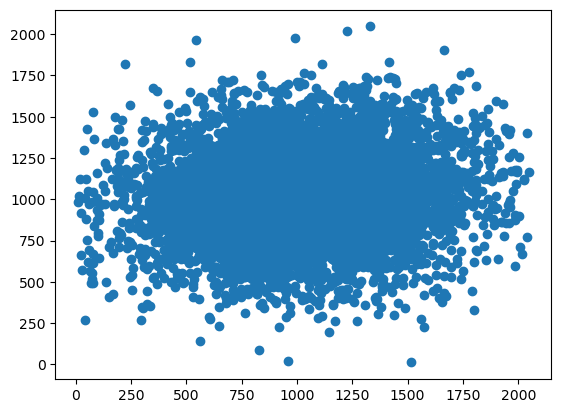

In [10]:
flag = src.mags['F158'] < 27
plt.scatter(src.x[flag], src.y[flag])

In [14]:
from rosesim.utils import get_subpixel_dither

In [15]:
from galsim import roman
import warnings
from copy import deepcopy
import astrocut
from astrocut import get_center_pixel, ASDFCutout
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

Dither in pixels:
 [[0.         0.        ]
 [0.09090909 0.90909091]
 [0.63636364 0.36363636]
 [0.18181818 0.81818182]
 [0.27272727 0.72727273]]


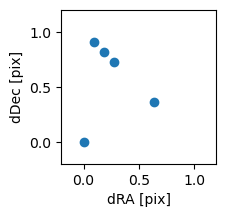

In [18]:
pattern = 'LINEGAP5_1'
# pattern = 'BOXGAP4_1'
# pattern = 'SUB4'
dither_pattern = get_subpixel_dither(obs_ra, obs_dec, pattern=pattern, display=True)

In [23]:
for i, dither in enumerate(dither_pattern[:]):
    print('dither', dither)
    gal.load_src(src, ra=obs_ra, dec=obs_dec) # the ra, dec of the input galaxy doesn't change with dither

    for filt in ['F106', 'F158']: # 'F106', 
        t_exp = 600
        gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky_2048/{filt}_{t_exp}s.asdf')
        # gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf')
        gal.gen_catalog()
        gal.apply_dither(dither[0], dither[1])
        gal.observe(exptimes=t_exp, psftype='epsf', fastpointsources=True)
        gal.dm.save(f'./{filt}_{t_exp}s.{pattern}.dither{i}.asdf')
        rosesim.utils.asdf_to_fits(gal.dm, f'./{filt}_{t_exp}s_{pattern}.{i}.fits', subtract_bkg=False)

dither (np.float64(0.0), np.float64(0.0))
Loaded background from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky_2048/F106_600s.asdf


Catalogue generated.
Cut 1041 objects outside of the image.


2026-02-23 01:35:38 INFO     Setting pixscale to match default.


2026-02-23 01:35:38 WARNING  wcs is None; unlikely to get orientation of PSF correct.


2026-02-23 01:35:38 INFO     Creating PSF from CRDS reference type epsf


...

2026-02-23 01:42:20 INFO     Adding 171738 sources to image...


2026-02-23 01:42:27 WARNING  Adding noise to each star individually.


2026-02-23 01:42:49 INFO     Rendered 171738 point sources in 22.1 seconds


2026-02-23 01:42:49 INFO     Rendered 171738 total sources in 22.1 seconds


Successfully wrote FITS file: ./F158_600s_LINEGAP5_1.4.fits


In [126]:
img = gal.dm.data
show_image_wcs(img - np.median(img), cmap='Greys', figsize=(9, 9))

In [319]:
# show_image_wcs(gal.dm.data)

In [33]:
asdf_cutout = ASDFCutout("./F106_642s_temp.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)

img = asdf_cutout.cutouts[0].data 
show_image_wcs(img - np.median(img), cmap='Greys', figsize=(5, 5))

In [39]:
asdf_cutout = ASDFCutout("./F106_600s.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)

img = asdf_cutout.cutouts[0].data 
show_image_wcs(img - np.median(img), cmap='Greys', figsize=(9, 9))

In [329]:
asdf_cutout = ASDFCutout("./F106_642s.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)

img = asdf_cutout.cutouts[0].data 
show_image_wcs(img - np.median(img), cmap='Greys', figsize=(5, 5))

In [24]:
asdf_cutout = ASDFCutout("./F106_642s.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)

img = asdf_cutout.cutouts[0].data 
show_image_wcs(img - np.median(img), cmap='Greys', figsize=(5, 5))

In [13]:
# dm = rosesim.utils.read_L3_asdf('./F158_642s.asdf')
# psf = dm.psf

In [45]:
dm = rosesim.read_L3_asdf('./F106_642s.asdf')

In [193]:
rosesim.utils.asdf_to_fits(dm, './test.fits', subtract_bkg=True)

In [162]:
rosesim.asdf_to_fits(gal.dm, f'{filt}_642s.fits', subtract_bkg=True)

# Visualize

In [26]:
from astropy.visualization import make_lupton_rgb
import sep

zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


In [27]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_3.5Mpc_napping_sfh_n253'

In [28]:
prefix = 'ufd_1e6_25Mpc_1.0Gyr'
# prefix = 'dw_1e5.5_20Mpc_1.0Gyr'
prefix = 'dw_1e7.0_35Mpc_0.4Gyr'
# prefix = 'ufd_1e3_2Mpc_0.4Gyr'
# prefix = 'dw_1e5.5_2Mpc_2.0Gyr'
prefix = 'dw_1e5.5_2Mpc_age9.6_feh-1.5'
# prefix = 'dw_1e6.0_2Mpc_age9.6_feh-1.5'
# prefix = 'dw_1e4.5_3.0Mpc_age9.6_feh-2.0'
# prefix = 'dw_1e6.0_10.0Mpc_age9.6_feh-2.0'
# prefix = 'dw_1e6.0_2.0Mpc_age9.6_feh-2.0'
prefix = 'dw_1e5.5_2.0Mpc_age9.6_feh-1.5'
prefix = 'dw_1e7.0_3.5Mpc_napping_sfh_n253'

In [30]:
obs_ra, obs_dec = 150, 0
# obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

In [31]:
cen_ra, cen_dec = obs_ra, obs_dec
import sep

In [34]:
filters = ['F106', 'F158']
imgs = []
# t_exp = 10272
# t_exp = 642
t_exp = 600
for filt in filters:
    file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_{t_exp}s.LINEGAP5_1.dither0.asdf", 
    # file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf", 
    # file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal/{filt}_642s.asdf", 
    asdf_cutout = ASDFCutout(file,
                             SkyCoord(cen_ra, cen_dec, unit='deg'), 2000) # 5001
    # SkyCoord(obs_ra, obs_dec, unit='deg'), 4069) # 5001
    
    hdu = asdf_cutout.fits_cutouts[0]
    img = hdu[1].data
    bkg = sep.Background(img, bw=256, bh=256)
    hdu[1].data -= bkg.globalback
    # hdu.writeto(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_{t_exp}s_cutout.fits', overwrite=True)

    img *= 10**(0.4 * (27 - zp))
    # imgs.append(img[250:1250, :])
    imgs.append(img[:, :])

/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')
2026-02-23 01:44:14 WARNING  ModuleWarning: The `stdatamodels` package cannot be imported; ASDF-in-FITS embedding will be skipped for these cutouts. Install the optional dependency with: pip install "astrocut[all]" or pip install stdatamodels>=4.1.0


/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')
2026-02-23 01:44:14 WARNING  ModuleWarning: The `stdatamodels` package cannot be imported; ASDF-in-FITS embedding will be skipped for these cutouts. Install the optional dependency with: pip install "astrocut[all]" or pip install stdatamodels>=4.1.0


In [107]:
import rosesim

(np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5))

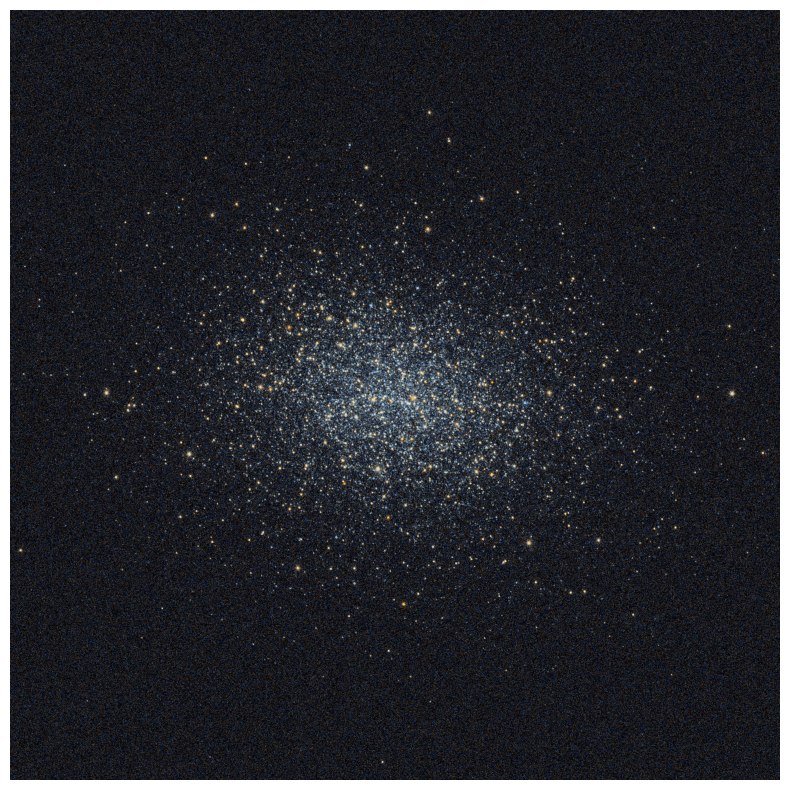

In [35]:
# rgb = make_lupton_rgb(0.95 * imgs[2], 1.15 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=0.2, Q=3)
rgb = make_lupton_rgb(0.9 * imgs[1], 1.05 * 0.5 * (imgs[1] + imgs[0]), 1.15 * imgs[0], minimum=-0.01, stretch=0.3, Q=3)
fig, ax = plt.subplots(figsize=(10, 10))
# fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb) #, origin='lower')
plt.axis('off')

# plt.text(wid - 0.2 * wid, +5, filters[filt_idx[0]], 
         # fontsize=20, color='deepskyblue', va='center', ha='center')
# plt.text(wid, +5, filters[filt_idx[1]], 
         # fontsize=20, color='limegreen', va='center', ha='center')
# plt.text(wid + 0.2 * wid, +5, filters[filt_idx[2]], 
         # fontsize=20, color='orangered', va='center', ha='center')
# title = prefix
# plt.title(title, fontsize=20)

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True, pad_inches=0)
# plt.close()